## Project Abstract

This project develops a multiclass classification system to predict crash severity using the Chicago Traffic Crash dataset. The primary stakeholders include city transportation authorities, emergency responders, and policy makers aiming to reduce high-risk incidents and improve response strategies.

The dataset consists of crash-level, vehicle-level, and person-level data, which were aggregated to avoid duplication bias and ensure a consistent modeling unit. Key preprocessing steps included handling missing values, removing data leakage features, encoding categorical variables using one-hot encoding, and addressing class imbalance using SMOTE.

A baseline Logistic Regression model was implemented, followed by more advanced ensemble methods including Random Forest and XGBoost. Hyperparameter tuning was conducted using GridSearchCV with cross-validation to optimize model performance.

Model evaluation focused on Macro F1 score due to class imbalance, alongside accuracy and weighted F1. A reusable evaluation function was implemented to ensure consistent comparison across models, including confusion matrix visualization.

Interpretability techniques such as feature importance and SHAP values were used to understand model behavior. The final tuned model and preprocessing artifacts were saved for deployment.

This workflow demonstrates a production-ready machine learning pipeline from data preprocessing to model evaluation and deployment.
# Business Understanding

## Problem Statement
The goal of this project is to develop a machine learning model that predicts the primary contributory cause of traffic crashes in Chicago, enabling stakeholders to identify high-risk conditions and design targeted interventions to improve road safety.

##  Objectives
- Build a classification model to predict crash causes
- Identify key factors contributing to traffic accidents
- Provide insights that can help reduce accidents

##  Stakeholders
- Chicago City Planners → prioritize infrastructure improvements (e.g., intersections, lighting)
- Traffic Safety Authorities → design targeted safety campaigns and enforcement strategies
- Policy Makers → implement data-driven regulations to reduce high-risk crash scenarios

##  Analytical Approach (Revised)

This problem is framed as a multiclass classification task.

However, it is important to clarify that:

- The target variable (PRIM_CONTRIBUTORY_CAUSE) is assigned after crash investigation
- Therefore, this model is not a real-time predictive system
- Instead, it is a **diagnostic classification model**

### Modeling Goal

To identify patterns between:
- environmental conditions
- roadway characteristics
- aggregated participant features

and the reported crash causes.

This allows stakeholders to understand **high-risk conditions**, rather than predict crashes in advance.
##  Success Criteria
The success of the model will be evaluated using:
- Macro F1-score (to handle class imbalance)
- Confusion matrix (to understand misclassifications)
- Interpretability (feature importance analysis)
- Baseline comparison (e.g., majority class or simple model)

##  Key Challenges
- Imbalanced target classes
- High number of categorical variables
- Data spread across multiple tables (crashes, vehicles, people)
- Risk of data leakage: Some variables may contain information that is only known after the crash occurs (e.g., injury severity, damage estimates). These must be carefully excluded to avoid data leakage and ensure the model reflects real-world prediction scenarios.

#  Data Understanding

### Unit of Analysis
The primary unit of analysis will be at the crash level. Therefore, vehicle-level and person-level data will need to be aggregated to align with the crash-level target variable.

## Dataset Description
This project uses three datasets provided by the City of Chicago:

- **Crashes Dataset**: Contains information about each traffic crash (e.g., time, location, weather conditions, road conditions).
- **Vehicles Dataset**: Contains details about the vehicles involved in each crash.
- **People Dataset**: Contains information about drivers and passengers involved in each crash.

These datasets are related through a common key: `CRASH_RECORD_ID`.

## Objective of This Section
- Load the datasets
- Understand their structure
- Identify key columns
- Perform initial exploration

In [2]:
#import pandas library 
import pandas as pd

# Load datasets
crashes = pd.read_csv("../Data/Raw/Traffic_Crashes.csv", low_memory=False)
vehicles = pd.read_csv("../Data/Raw/vehicle_data.csv", low_memory=False)
people = pd.read_csv("../Data/Raw/passenger_driver.csv", low_memory=False)

# Display shapes
print("Crashes shape:", crashes.shape)
print("Vehicles shape:", vehicles.shape)
print("People shape:", people.shape)

Crashes shape: (251295, 48)
Vehicles shape: (511366, 71)
People shape: (550849, 29)


## Data Structure Inspection

Before performing exploratory analysis, we examine the structure of each dataset, including:
- Column names and meanings
- Data types
- Missing values
- Summary statistics

This helps identify data quality issues and informs preprocessing decisions.

In [3]:
print("Crashes Columns:")
print(crashes.columns.tolist())

print("\nVehicles Columns:")
print(vehicles.columns.tolist())

print("\nPeople Columns:")
print(people.columns.tolist())

Crashes Columns:
['CRASH_RECORD_ID', 'CRASH_DATE_EST_I', 'CRASH_DATE', 'POSTED_SPEED_LIMIT', 'TRAFFIC_CONTROL_DEVICE', 'DEVICE_CONDITION', 'WEATHER_CONDITION', 'LIGHTING_CONDITION', 'FIRST_CRASH_TYPE', 'TRAFFICWAY_TYPE', 'LANE_CNT', 'ALIGNMENT', 'ROADWAY_SURFACE_COND', 'ROAD_DEFECT', 'REPORT_TYPE', 'CRASH_TYPE', 'INTERSECTION_RELATED_I', 'NOT_RIGHT_OF_WAY_I', 'HIT_AND_RUN_I', 'DAMAGE', 'DATE_POLICE_NOTIFIED', 'PRIM_CONTRIBUTORY_CAUSE', 'SEC_CONTRIBUTORY_CAUSE', 'STREET_NO', 'STREET_DIRECTION', 'STREET_NAME', 'BEAT_OF_OCCURRENCE', 'PHOTOS_TAKEN_I', 'STATEMENTS_TAKEN_I', 'DOORING_I', 'WORK_ZONE_I', 'WORK_ZONE_TYPE', 'WORKERS_PRESENT_I', 'NUM_UNITS', 'MOST_SEVERE_INJURY', 'INJURIES_TOTAL', 'INJURIES_FATAL', 'INJURIES_INCAPACITATING', 'INJURIES_NON_INCAPACITATING', 'INJURIES_REPORTED_NOT_EVIDENT', 'INJURIES_NO_INDICATION', 'INJURIES_UNKNOWN', 'CRASH_HOUR', 'CRASH_DAY_OF_WEEK', 'CRASH_MONTH', 'LATITUDE', 'LONGITUDE', 'LOCATION']

Vehicles Columns:
['CRASH_UNIT_ID', 'CRASH_RECORD_ID', 'CRASH

In [4]:
# crashes data types and missing values
crashes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251295 entries, 0 to 251294
Data columns (total 48 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   CRASH_RECORD_ID                251295 non-null  object 
 1   CRASH_DATE_EST_I               16190 non-null   object 
 2   CRASH_DATE                     251295 non-null  object 
 3   POSTED_SPEED_LIMIT             251295 non-null  int64  
 4   TRAFFIC_CONTROL_DEVICE         251295 non-null  object 
 5   DEVICE_CONDITION               251295 non-null  object 
 6   WEATHER_CONDITION              251295 non-null  object 
 7   LIGHTING_CONDITION             251295 non-null  object 
 8   FIRST_CRASH_TYPE               251295 non-null  object 
 9   TRAFFICWAY_TYPE                251295 non-null  object 
 10  LANE_CNT                       32 non-null      float64
 11  ALIGNMENT                      251295 non-null  object 
 12  ROADWAY_SURFACE_COND          

In [5]:
# vehicles data types and missing values
vehicles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 511366 entries, 0 to 511365
Data columns (total 71 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   CRASH_UNIT_ID             511366 non-null  int64  
 1   CRASH_RECORD_ID           511366 non-null  object 
 2   CRASH_DATE                511366 non-null  object 
 3   UNIT_NO                   511366 non-null  int64  
 4   UNIT_TYPE                 511020 non-null  object 
 5   NUM_PASSENGERS            74864 non-null   float64
 6   VEHICLE_ID                497726 non-null  float64
 7   CMRC_VEH_I                9295 non-null    object 
 8   MAKE                      497726 non-null  object 
 9   MODEL                     497726 non-null  object 
 10  LIC_PLATE_STATE           453010 non-null  object 
 11  VEHICLE_YEAR              427944 non-null  float64
 12  VEHICLE_DEFECT            497726 non-null  object 
 13  VEHICLE_TYPE              497726 non-null  o

In [6]:
# people data types and missing values
people.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550849 entries, 0 to 550848
Data columns (total 29 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   PERSON_ID              550849 non-null  object 
 1   PERSON_TYPE            550849 non-null  object 
 2   CRASH_RECORD_ID        550849 non-null  object 
 3   VEHICLE_ID             537572 non-null  float64
 4   CRASH_DATE             550849 non-null  object 
 5   SEAT_NO                109115 non-null  float64
 6   CITY                   402011 non-null  object 
 7   STATE                  409448 non-null  object 
 8   ZIPCODE                380516 non-null  object 
 9   SEX                    540181 non-null  object 
 10  AGE                    394788 non-null  float64
 11  DRIVERS_LICENSE_STATE  325326 non-null  object 
 12  DRIVERS_LICENSE_CLASS  255549 non-null  object 
 13  SAFETY_EQUIPMENT       549376 non-null  object 
 14  AIRBAG_DEPLOYED        538046 non-nu

### Key Observations from Data Structure Inspection

- The crashes dataset contains 251,295 records with 47 features, representing crash-level information such as weather, lighting, road conditions, and crash outcomes.
- The vehicles dataset contains 511,366 records with 70 features, indicating that multiple vehicles can be involved in a single crash.
- The people dataset contains 550,849 records with 28 features, showing that multiple individuals are associated with each crash.

- The datasets are linked using the `CRASH_RECORD_ID`, confirming a relational structure.

- The crashes dataset contains a mix of numerical and categorical variables, with several columns having significant missing values.

- The vehicles dataset has many columns related to commercial vehicles and hazardous materials, most of which have very high missing values and may not be useful for this analysis.

- The people dataset includes detailed driver and passenger information, but also contains several columns with substantial missing data.

- Columns with extremely high missing values (e.g., hazardous material indicators) will be evaluated for removal due to limited informational value.

These observations will guide feature selection, aggregation, and data cleaning in subsequent steps.

##  Exploratory Data Analysis (EDA)

In this section, we explore the datasets to understand:
- Distribution of the target variable
- Key patterns in crash conditions
- Potential relationships between features and crash causes
- Data quality issues such as missing values and inconsistencies

In [7]:
# Target Variable Distribution
crashes['PRIM_CONTRIBUTORY_CAUSE'].value_counts().head(10)

PRIM_CONTRIBUTORY_CAUSE
UNABLE TO DETERMINE                       103475
FAILING TO YIELD RIGHT-OF-WAY              29452
FOLLOWING TOO CLOSELY                      22284
IMPROPER OVERTAKING/PASSING                13651
NOT APPLICABLE                             11930
FAILING TO REDUCE SPEED TO AVOID CRASH     10223
DRIVING SKILLS/KNOWLEDGE/EXPERIENCE        10023
IMPROPER TURNING/NO SIGNAL                  8721
IMPROPER LANE USAGE                         8330
IMPROPER BACKING                            7805
Name: count, dtype: int64

In [8]:
#check for imbalance
crashes['PRIM_CONTRIBUTORY_CAUSE'].value_counts(normalize=True).head(10)

PRIM_CONTRIBUTORY_CAUSE
UNABLE TO DETERMINE                       0.411767
FAILING TO YIELD RIGHT-OF-WAY             0.117201
FOLLOWING TOO CLOSELY                     0.088677
IMPROPER OVERTAKING/PASSING               0.054323
NOT APPLICABLE                            0.047474
FAILING TO REDUCE SPEED TO AVOID CRASH    0.040681
DRIVING SKILLS/KNOWLEDGE/EXPERIENCE       0.039885
IMPROPER TURNING/NO SIGNAL                0.034704
IMPROPER LANE USAGE                       0.033148
IMPROPER BACKING                          0.031059
Name: proportion, dtype: float64

 The target variable is highly imbalanced, with "UNABLE TO DETERMINE" accounting for over 40% of observations. This category does not represent a meaningful crash cause and will be excluded to improve model interpretability and predictive value.


In [9]:
crashes = crashes[
    ~crashes['PRIM_CONTRIBUTORY_CAUSE'].isin([
        'UNABLE TO DETERMINE',
        'NOT APPLICABLE'
    ])
].copy()

### Target cleaning
 We removed 'UNABLE TO DETERMINE' and 'NOT applicable' because:
 
 - They dont represent actionable crash causes
 - Including them would reduce model interpretability
 - The goal is to focus on meaningful, intervention-relevant categories

 We have overwrite the original dataset to ensure consistency throughout the pipeline.



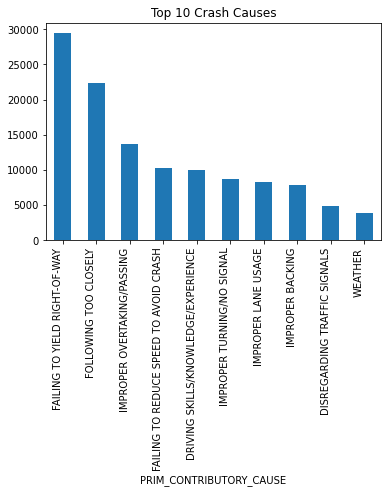

In [10]:
# visualize target variable 
import matplotlib.pyplot as plt

crashes['PRIM_CONTRIBUTORY_CAUSE'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Crash Causes")
plt.xticks(rotation=90,ha='right')
plt.show()

In [11]:
#check missing values
missing = crashes.isnull().mean().sort_values(ascending=False)
missing.head(10)

LANE_CNT              0.999823
WORKERS_PRESENT_I     0.998823
DOORING_I             0.996990
WORK_ZONE_TYPE        0.996475
WORK_ZONE_I           0.994974
PHOTOS_TAKEN_I        0.978365
NOT_RIGHT_OF_WAY_I    0.966524
STATEMENTS_TAKEN_I    0.963228
CRASH_DATE_EST_I      0.955148
HIT_AND_RUN_I         0.746707
dtype: float64

In [12]:
high_missing = missing[missing>0.9]

print("Dropping columns due to >90% missing:")
print(high_missing.index.tolist())
crashes = crashes.drop(columns=high_missing.index)

Dropping columns due to >90% missing:
['LANE_CNT', 'WORKERS_PRESENT_I', 'DOORING_I', 'WORK_ZONE_TYPE', 'WORK_ZONE_I', 'PHOTOS_TAKEN_I', 'NOT_RIGHT_OF_WAY_I', 'STATEMENTS_TAKEN_I', 'CRASH_DATE_EST_I']


Columns with more than 90% missing values were removed because:
- they provide insufficient signal
- imputation would introduce noise into the model.
- most are domain specific and are rarely recorded fields

In [13]:
#check key feature vs target
pd.crosstab(crashes['WEATHER_CONDITION'], crashes['PRIM_CONTRIBUTORY_CAUSE'])

PRIM_CONTRIBUTORY_CAUSE,ANIMAL,BICYCLE ADVANCING LEGALLY ON RED LIGHT,CELL PHONE USE OTHER THAN TEXTING,DISREGARDING OTHER TRAFFIC SIGNS,DISREGARDING ROAD MARKINGS,DISREGARDING STOP SIGN,DISREGARDING TRAFFIC SIGNALS,DISREGARDING YIELD SIGN,DISTRACTION - FROM INSIDE VEHICLE,DISTRACTION - FROM OUTSIDE VEHICLE,...,PASSING STOPPED SCHOOL BUS,PHYSICAL CONDITION OF DRIVER,RELATED TO BUS STOP,ROAD CONSTRUCTION/MAINTENANCE,ROAD ENGINEERING/SURFACE/MARKING DEFECTS,TEXTING,TURNING RIGHT ON RED,UNDER THE INFLUENCE OF ALCOHOL/DRUGS (USE WHEN ARREST IS EFFECTED),"VISION OBSCURED (SIGNS, TREE LIMBS, BUILDINGS, ETC.)",WEATHER
WEATHER_CONDITION,,,,,,,,,,,,,,,,,,,,,
"BLOWING SAND, SOIL, DIRT",0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
BLOWING SNOW,0,0,1,0,0,1,7,0,0,0,...,0,3,0,0,0,0,0,0,2,60
CLEAR,187,15,229,379,245,1774,4011,26,1232,624,...,26,1105,202,285,288,52,167,917,1134,488
CLOUDY/OVERCAST,2,0,6,7,11,64,157,0,44,23,...,1,54,7,6,18,0,7,21,64,85
FOG/SMOKE/HAZE,0,0,1,3,0,1,6,0,2,0,...,0,1,1,1,2,0,0,2,1,15
FREEZING RAIN/DRIZZLE,1,0,0,3,1,9,21,0,6,2,...,0,3,0,0,4,0,0,4,3,344
OTHER,0,0,0,4,1,7,17,0,2,4,...,0,0,2,1,0,0,0,3,7,107
RAIN,11,0,14,29,21,191,434,6,88,45,...,4,83,11,18,27,2,18,85,84,1055
SEVERE CROSS WIND GATE,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,12


In [14]:
#normalize weather conditions
pd.crosstab(
    crashes['WEATHER_CONDITION'], 
    crashes['PRIM_CONTRIBUTORY_CAUSE'],
    normalize='index'
    )

PRIM_CONTRIBUTORY_CAUSE,ANIMAL,BICYCLE ADVANCING LEGALLY ON RED LIGHT,CELL PHONE USE OTHER THAN TEXTING,DISREGARDING OTHER TRAFFIC SIGNS,DISREGARDING ROAD MARKINGS,DISREGARDING STOP SIGN,DISREGARDING TRAFFIC SIGNALS,DISREGARDING YIELD SIGN,DISTRACTION - FROM INSIDE VEHICLE,DISTRACTION - FROM OUTSIDE VEHICLE,...,PASSING STOPPED SCHOOL BUS,PHYSICAL CONDITION OF DRIVER,RELATED TO BUS STOP,ROAD CONSTRUCTION/MAINTENANCE,ROAD ENGINEERING/SURFACE/MARKING DEFECTS,TEXTING,TURNING RIGHT ON RED,UNDER THE INFLUENCE OF ALCOHOL/DRUGS (USE WHEN ARREST IS EFFECTED),"VISION OBSCURED (SIGNS, TREE LIMBS, BUILDINGS, ETC.)",WEATHER
WEATHER_CONDITION,,,,,,,,,,,,,,,,,,,,,
"BLOWING SAND, SOIL, DIRT",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.125000,0.125000
BLOWING SNOW,0.000000,0.000000,0.006711,0.000000,0.000000,0.006711,0.046980,0.000000,0.000000,0.000000,...,0.000000,0.020134,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.013423,0.402685
CLEAR,0.001714,0.000137,0.002099,0.003474,0.002246,0.016261,0.036766,0.000238,0.011293,0.005720,...,0.000238,0.010129,0.001852,0.002612,0.002640,0.000477,0.001531,0.008406,0.010395,0.004473
CLOUDY/OVERCAST,0.000449,0.000000,0.001347,0.001572,0.002470,0.014372,0.035257,0.000000,0.009881,0.005165,...,0.000225,0.012127,0.001572,0.001347,0.004042,0.000000,0.001572,0.004716,0.014372,0.019088
FOG/SMOKE/HAZE,0.000000,0.000000,0.005814,0.017442,0.000000,0.005814,0.034884,0.000000,0.011628,0.000000,...,0.000000,0.005814,0.005814,0.005814,0.011628,0.000000,0.000000,0.011628,0.005814,0.087209
FREEZING RAIN/DRIZZLE,0.001376,0.000000,0.000000,0.004127,0.001376,0.012380,0.028886,0.000000,0.008253,0.002751,...,0.000000,0.004127,0.000000,0.000000,0.005502,0.000000,0.000000,0.005502,0.004127,0.473177
OTHER,0.000000,0.000000,0.000000,0.008584,0.002146,0.015021,0.036481,0.000000,0.004292,0.008584,...,0.000000,0.000000,0.004292,0.002146,0.000000,0.000000,0.000000,0.006438,0.015021,0.229614
RAIN,0.001053,0.000000,0.001340,0.002777,0.002011,0.018288,0.041555,0.000574,0.008426,0.004309,...,0.000383,0.007947,0.001053,0.001723,0.002585,0.000191,0.001723,0.008139,0.008043,0.101015
SEVERE CROSS WIND GATE,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.521739


In [15]:
pd.crosstab(crashes['LIGHTING_CONDITION'], crashes['PRIM_CONTRIBUTORY_CAUSE'])

PRIM_CONTRIBUTORY_CAUSE,ANIMAL,BICYCLE ADVANCING LEGALLY ON RED LIGHT,CELL PHONE USE OTHER THAN TEXTING,DISREGARDING OTHER TRAFFIC SIGNS,DISREGARDING ROAD MARKINGS,DISREGARDING STOP SIGN,DISREGARDING TRAFFIC SIGNALS,DISREGARDING YIELD SIGN,DISTRACTION - FROM INSIDE VEHICLE,DISTRACTION - FROM OUTSIDE VEHICLE,...,PASSING STOPPED SCHOOL BUS,PHYSICAL CONDITION OF DRIVER,RELATED TO BUS STOP,ROAD CONSTRUCTION/MAINTENANCE,ROAD ENGINEERING/SURFACE/MARKING DEFECTS,TEXTING,TURNING RIGHT ON RED,UNDER THE INFLUENCE OF ALCOHOL/DRUGS (USE WHEN ARREST IS EFFECTED),"VISION OBSCURED (SIGNS, TREE LIMBS, BUILDINGS, ETC.)",WEATHER
LIGHTING_CONDITION,,,,,,,,,,,,,,,,,,,,,
DARKNESS,15,1,16,19,3,94,185,1,60,37,...,1,67,3,11,21,4,11,82,28,253
"DARKNESS, LIGHTED ROAD",83,2,79,130,70,603,1755,7,394,223,...,4,408,39,70,96,24,54,703,185,1233
DAWN,8,0,4,19,8,41,114,0,39,18,...,0,40,6,4,6,1,6,30,18,114
DAYLIGHT,99,11,151,260,194,1325,2630,22,887,413,...,28,742,176,237,238,24,122,224,1074,2023
DUSK,5,1,9,14,9,64,135,2,36,22,...,1,35,7,4,6,2,7,26,28,111
UNKNOWN,12,0,6,8,12,42,40,1,26,17,...,0,12,0,10,7,3,0,2,7,83


In [16]:
#normalize the lighting conditions
pd.crosstab(
    crashes['LIGHTING_CONDITION'], 
    crashes['PRIM_CONTRIBUTORY_CAUSE'],
    normalize='index'
    )

PRIM_CONTRIBUTORY_CAUSE,ANIMAL,BICYCLE ADVANCING LEGALLY ON RED LIGHT,CELL PHONE USE OTHER THAN TEXTING,DISREGARDING OTHER TRAFFIC SIGNS,DISREGARDING ROAD MARKINGS,DISREGARDING STOP SIGN,DISREGARDING TRAFFIC SIGNALS,DISREGARDING YIELD SIGN,DISTRACTION - FROM INSIDE VEHICLE,DISTRACTION - FROM OUTSIDE VEHICLE,...,PASSING STOPPED SCHOOL BUS,PHYSICAL CONDITION OF DRIVER,RELATED TO BUS STOP,ROAD CONSTRUCTION/MAINTENANCE,ROAD ENGINEERING/SURFACE/MARKING DEFECTS,TEXTING,TURNING RIGHT ON RED,UNDER THE INFLUENCE OF ALCOHOL/DRUGS (USE WHEN ARREST IS EFFECTED),"VISION OBSCURED (SIGNS, TREE LIMBS, BUILDINGS, ETC.)",WEATHER
LIGHTING_CONDITION,,,,,,,,,,,,,,,,,,,,,
DARKNESS,0.002814,0.000188,0.003001,0.003564,0.000563,0.017633,0.034703,0.000188,0.011255,0.006941,...,0.000188,0.012568,0.000563,0.002063,0.003939,0.000750,0.002063,0.015382,0.005252,0.047458
"DARKNESS, LIGHTED ROAD",0.002729,0.000066,0.002598,0.004275,0.002302,0.019828,0.057707,0.000230,0.012955,0.007333,...,0.000132,0.013416,0.001282,0.002302,0.003157,0.000789,0.001776,0.023116,0.006083,0.040543
DAWN,0.003413,0.000000,0.001706,0.008106,0.003413,0.017491,0.048635,0.000000,0.016638,0.007679,...,0.000000,0.017065,0.002560,0.001706,0.002560,0.000427,0.002560,0.012799,0.007679,0.048635
DAYLIGHT,0.001096,0.000122,0.001672,0.002879,0.002149,0.014674,0.029127,0.000244,0.009823,0.004574,...,0.000310,0.008218,0.001949,0.002625,0.002636,0.000266,0.001351,0.002481,0.011894,0.022404
DUSK,0.001260,0.000252,0.002268,0.003528,0.002268,0.016129,0.034022,0.000504,0.009073,0.005544,...,0.000252,0.008821,0.001764,0.001008,0.001512,0.000504,0.001764,0.006552,0.007056,0.027974
UNKNOWN,0.003390,0.000000,0.001695,0.002260,0.003390,0.011864,0.011299,0.000282,0.007345,0.004802,...,0.000000,0.003390,0.000000,0.002825,0.001977,0.000847,0.000000,0.000565,0.001977,0.023446


### Identifying leaking features

In [17]:
crashes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 135890 entries, 1 to 251293
Data columns (total 39 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   CRASH_RECORD_ID                135890 non-null  object 
 1   CRASH_DATE                     135890 non-null  object 
 2   POSTED_SPEED_LIMIT             135890 non-null  int64  
 3   TRAFFIC_CONTROL_DEVICE         135890 non-null  object 
 4   DEVICE_CONDITION               135890 non-null  object 
 5   WEATHER_CONDITION              135890 non-null  object 
 6   LIGHTING_CONDITION             135890 non-null  object 
 7   FIRST_CRASH_TYPE               135890 non-null  object 
 8   TRAFFICWAY_TYPE                135890 non-null  object 
 9   ALIGNMENT                      135890 non-null  object 
 10  ROADWAY_SURFACE_COND           135890 non-null  object 
 11  ROAD_DEFECT                    135890 non-null  object 
 12  REPORT_TYPE                    1294

In [18]:
people.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550849 entries, 0 to 550848
Data columns (total 29 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   PERSON_ID              550849 non-null  object 
 1   PERSON_TYPE            550849 non-null  object 
 2   CRASH_RECORD_ID        550849 non-null  object 
 3   VEHICLE_ID             537572 non-null  float64
 4   CRASH_DATE             550849 non-null  object 
 5   SEAT_NO                109115 non-null  float64
 6   CITY                   402011 non-null  object 
 7   STATE                  409448 non-null  object 
 8   ZIPCODE                380516 non-null  object 
 9   SEX                    540181 non-null  object 
 10  AGE                    394788 non-null  float64
 11  DRIVERS_LICENSE_STATE  325326 non-null  object 
 12  DRIVERS_LICENSE_CLASS  255549 non-null  object 
 13  SAFETY_EQUIPMENT       549376 non-null  object 
 14  AIRBAG_DEPLOYED        538046 non-nu

In [19]:
vehicles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 511366 entries, 0 to 511365
Data columns (total 71 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   CRASH_UNIT_ID             511366 non-null  int64  
 1   CRASH_RECORD_ID           511366 non-null  object 
 2   CRASH_DATE                511366 non-null  object 
 3   UNIT_NO                   511366 non-null  int64  
 4   UNIT_TYPE                 511020 non-null  object 
 5   NUM_PASSENGERS            74864 non-null   float64
 6   VEHICLE_ID                497726 non-null  float64
 7   CMRC_VEH_I                9295 non-null    object 
 8   MAKE                      497726 non-null  object 
 9   MODEL                     497726 non-null  object 
 10  LIC_PLATE_STATE           453010 non-null  object 
 11  VEHICLE_YEAR              427944 non-null  float64
 12  VEHICLE_DEFECT            497726 non-null  object 
 13  VEHICLE_TYPE              497726 non-null  o

- Target variable - We drop unable to determinne and not applicable. They are not useful

### Features strongly affecting the target variable


In [20]:
# Features from the 'crashes' table
crash_cols = [
    'CRASH_RECORD_ID', 'PRIM_CONTRIBUTORY_CAUSE', 'WEATHER_CONDITION', 
    'LIGHTING_CONDITION', 'ROADWAY_SURFACE_COND', 'TRAFFICWAY_TYPE', 
    'ALIGNMENT', 'TRAFFIC_CONTROL_DEVICE', 'DEVICE_CONDITION', 
    'CRASH_HOUR', 'CRASH_DAY_OF_WEEK', 'CRASH_MONTH', 'POSTED_SPEED_LIMIT'
]

# Features from the 'vehicles' table
vehicle_cols = ['CRASH_RECORD_ID', 'MANEUVER', 'VEHICLE_TYPE']

# Features from the 'people' table
people_cols = ['CRASH_RECORD_ID', 'DRIVER_ACTION', 'DRIVER_VISION', 
               'PHYSICAL_CONDITION', 'AGE', 'SEX']

In [21]:
# Vehicle aggregation
vehicles_agg = vehicles.groupby('CRASH_RECORD_ID').agg({
    'VEHICLE_TYPE' : 'nunique',
    'MANEUVER' : lambda x: x.mode()[0] if not x.mode().empty else 'Unknown'
}).rename(columns={
    'VEHICLE_TYPE': 'num_vehicle_types',
    'MANEUVER': 'dominant_maneuver'
})

# People aggregation
people_agg = people.groupby('CRASH_RECORD_ID').agg({
    'AGE': 'mean',
    'SEX': lambda x: x.mode()[0] if not x.mode().empty else 'Unkown'
}).rename(columns={
    'AGE': 'avg_age',
    'SEX': 'dominant_sex'
})

# Extra Features
people_count = people.groupby('CRASH_RECORD_ID').size().rename('num_people')

#Merge
df_model = crashes.merge(vehicles_agg, on='CRASH_RECORD_ID', how='left')
df_model = df_model.merge(people_agg, on='CRASH_RECORD_ID', how='left')
df_model = df_model.merge(people_count, on='CRASH_RECORD_ID', how='left')


Since crashes can involve multiple vehicles and people, directly merging tables would duplicate rows.

To prevent this, we aggregate vehicle-level and person-level data to the crash-level.

This ensure:
- one row per crash
- no duplication bias
- meaningful summary feature

### ENVIRONMENT

1. - Weather condition - affects  visibility


2.  Lighting condition -visibility issues (night and dark)

### ROAD FEATURES

3. Road surface cond- are the roads slippery are they snowy. Due to the conditions of the road surface it is easier to loose control

4. Trafficway type - there are risks in intersections as well as the highway. In the highway incase the vehicle fails or the driver looses his attention ther is a high likelyhood of accidents as well as intersections incase a driver fails to use his side mirrors and indicate on time its also a high likelyhood

5. Alignment - curves increase accident likelihood especially when the curves and meandors are not signaled correctly(traffic signs )

### TRAFFIC FEATURES

6. Traffic control device - signal  and stop signs affect driver behaviour

7. Device codition - broken signals 

### VEHICLE FEATURES

9. Maneuver - what was the driver doing

10. Vehicle type - trucks vs cars are different on the road

11. Vehicle defect - mechanical issues

### PEOPLE

12. Driver Action - speeding , failure to give way

13. Driver vision - obstructions

14. Physical condition - driver is fatigued or ill

15. Age - there is a risk for the young vs old

16. Sex - behaviour differences

### TIME FEATURES

17. Crash hour - night vs day patterns

18. Crash day of week - patterns during weekdays and weekends

19. Crash month - seasonal patterns

### NUMERIC FEATURES

20. Posted speed limit- severity

### FEATURES TO IGNORE

- Injuries- it describes the outcome of the crash i.e. number of injuries and occur after the event
- Injury classification- its classified after the severity of harm sustained after the crash
- EMS/ Hospital- this is emergency response after the crash
- Damage - the level of damage is assessed after the crash
- Report type - done later by the police
- Towed - its a consequence of the crash not the crash cause it just tells the model how severe the crash was and the severity is not a cause
- Street name- has way too many value counts(high cardinality)
- make - high cardinality
- model- high cardinality
- cell phone use -few values
- hazmat- high imbalance, does not represent the crash populatiin
- trailer- its only for specific vehicle types


In [22]:
crashes['STREET_NAME'].value_counts()

STREET_NAME
WESTERN AVE    3858
PULASKI RD     3356
CICERO AVE     3228
ASHLAND AVE    3130
HALSTED ST     2703
               ... 
JEROME ST         1
LOGAN SD          1
HARBOR AVE        1
HOTEL DR          1
DAWSON AVE        1
Name: count, Length: 1344, dtype: int64

In [23]:
selected_features = [
    "WEATHER_CONDITION",
    "LIGHTING_CONDITION",
    "ROADWAY_SURFACE_COND",
    "TRAFFICWAY_TYPE",
    "ALIGNMENT",
    "TRAFFIC_CONTROL_DEVICE",
    "DEVICE_CONDITION",
    "MANEUVER",
    "VEHICLE_TYPE",
    "AGE",
    "SEX",
    "CRASH_HOUR",
    "CRASH_DAY_OF_WEEK",
    "CRASH_MONTH",
    "POSTED_SPEED_LIMIT"
]

We are telling python that it should only pick the 10 largest contributors  of weather conditions. We have also normalized the weather data and also avoid large data that will lead us to a trap

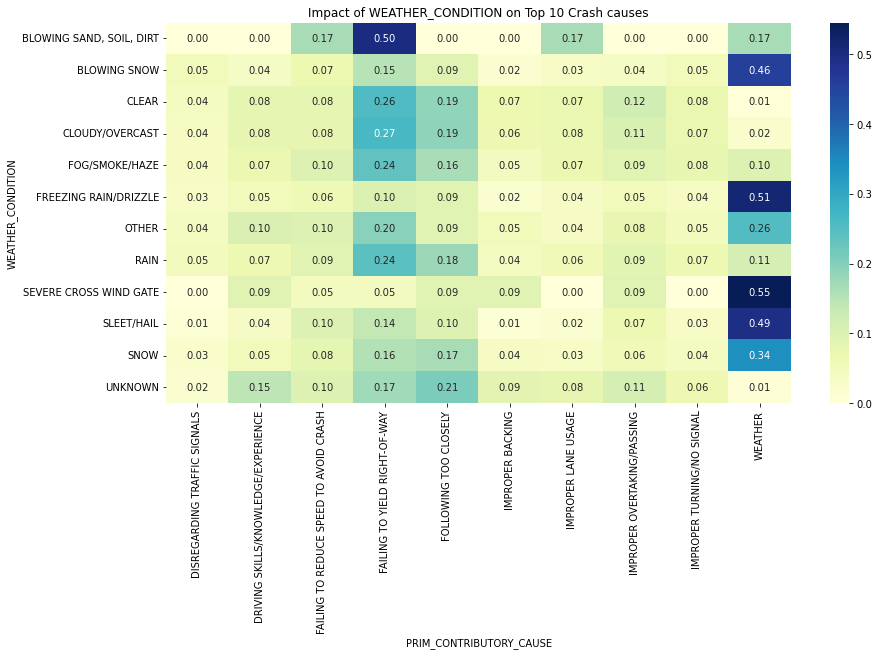

In [24]:
import seaborn as sns
def plot_category_heatmap(df, feature, target, top_n=10):
    top_targets = df[target].value_counts().nlargest(top_n).index
    subset = df[df[target].isin(top_targets)]
    
    
    ct = pd.crosstab(subset[feature], subset[target], normalize='index')
    
    plt.figure(figsize=(14, 7))
    sns.heatmap(ct, annot=True, cmap="YlGnBu", fmt=".2f")
    plt.title(f"Impact of {feature} on Top {top_n} Crash causes")
    plt.show()

plot_category_heatmap(df_model, 'WEATHER_CONDITION', 'PRIM_CONTRIBUTORY_CAUSE')

This a visualization of the numerical columns, we have used sharley=True to combine all 3 plots to use the same y-axis.
It shows how age,crash hour and speed affect our target variable

# **Target Variable Strategy**
- What Exactly Are We Predicting?

We are predicting:

The cause of the crash, not the outcome.

This means:

- We focus on driver behavior, environment, road, and vehicle conditions
- We exclude consequences of the crash.

In [25]:
# Choice of Target Variable
target = "PRIM_CONTRIBUTORY_CAUSE"

In [26]:
# Cleaning Target Variable
# Remove non-informative target classes
df_model = df_model[
    ~df_model['PRIM_CONTRIBUTORY_CAUSE'].isin(
        ['UNABLE TO DETERMINE', 'NOT APPLICABLE']
    )
]

#### Checking Target Distribution
- This answers the question of " Is it learnable?Hence we determine the distribution of thr Target Variable


In [27]:
# Check class distribution
target_counts = df_model['PRIM_CONTRIBUTORY_CAUSE'].value_counts()

print(target_counts.head(10))

PRIM_CONTRIBUTORY_CAUSE
FAILING TO YIELD RIGHT-OF-WAY             29452
FOLLOWING TOO CLOSELY                     22284
IMPROPER OVERTAKING/PASSING               13651
FAILING TO REDUCE SPEED TO AVOID CRASH    10223
DRIVING SKILLS/KNOWLEDGE/EXPERIENCE       10023
IMPROPER TURNING/NO SIGNAL                 8721
IMPROPER LANE USAGE                        8330
IMPROPER BACKING                           7805
DISREGARDING TRAFFIC SIGNALS               4859
WEATHER                                    3817
Name: count, dtype: int64


In [28]:
# Normalize distribution
target_distribution = df_model['PRIM_CONTRIBUTORY_CAUSE'].value_counts(normalize=True)

print(target_distribution.head(10))

PRIM_CONTRIBUTORY_CAUSE
FAILING TO YIELD RIGHT-OF-WAY             0.216734
FOLLOWING TOO CLOSELY                     0.163986
IMPROPER OVERTAKING/PASSING               0.100456
FAILING TO REDUCE SPEED TO AVOID CRASH    0.075230
DRIVING SKILLS/KNOWLEDGE/EXPERIENCE       0.073758
IMPROPER TURNING/NO SIGNAL                0.064177
IMPROPER LANE USAGE                       0.061300
IMPROPER BACKING                          0.057436
DISREGARDING TRAFFIC SIGNALS              0.035757
WEATHER                                   0.028089
Name: proportion, dtype: float64


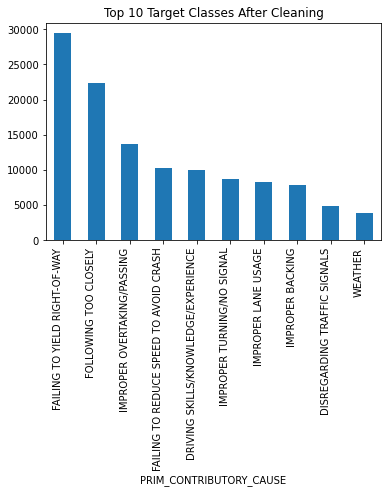

In [29]:
#Visualise Target Imbalance
import matplotlib.pyplot as plt

target_counts.head(10).plot(kind='bar')
plt.title("Top 10 Target Classes After Cleaning")
plt.xticks(rotation=90, ha='right')
plt.show()


Now, let us answer "Is this Target Learnable?" 
we do this by focusing on the Top N most frequent classes. This will help us because:
 - Improves Model Performance
 - Make our evaluation meaningful
 - Reduces Noise

In [30]:
# Select top 10 most frequent causes
top_n = 10

top_classes = df_model['PRIM_CONTRIBUTORY_CAUSE'].value_counts().nlargest(top_n).index

df_model = df_model[df_model['PRIM_CONTRIBUTORY_CAUSE'].isin(top_classes)]

print(f"Remaining classes: {len(top_classes)}")
print(top_classes)

Remaining classes: 10
Index(['FAILING TO YIELD RIGHT-OF-WAY', 'FOLLOWING TOO CLOSELY',
       'IMPROPER OVERTAKING/PASSING', 'FAILING TO REDUCE SPEED TO AVOID CRASH',
       'DRIVING SKILLS/KNOWLEDGE/EXPERIENCE', 'IMPROPER TURNING/NO SIGNAL',
       'IMPROPER LANE USAGE', 'IMPROPER BACKING',
       'DISREGARDING TRAFFIC SIGNALS', 'WEATHER'],
      dtype='object', name='PRIM_CONTRIBUTORY_CAUSE')


In [31]:
# Final Target Distribution
df_model['PRIM_CONTRIBUTORY_CAUSE'].value_counts()

PRIM_CONTRIBUTORY_CAUSE
FAILING TO YIELD RIGHT-OF-WAY             29452
FOLLOWING TOO CLOSELY                     22284
IMPROPER OVERTAKING/PASSING               13651
FAILING TO REDUCE SPEED TO AVOID CRASH    10223
DRIVING SKILLS/KNOWLEDGE/EXPERIENCE       10023
IMPROPER TURNING/NO SIGNAL                 8721
IMPROPER LANE USAGE                        8330
IMPROPER BACKING                           7805
DISREGARDING TRAFFIC SIGNALS               4859
WEATHER                                    3817
Name: count, dtype: int64

### Data Cleaning and Preparation
- Data Cleaning

To ensure the dataset is clean, consistent and suitable for training.  
This step is important because messy data can lead to incorrect patterns, poor model performance, and unreliable predictions.

### Cleaning Steps Performed

- **Removed duplicate records** to avoid repeated crashes affecting model learning.
- **Handled missing values** by either dropping rows with critical missing target values or imputing where appropriate.
- **Removed irrelevant identifier columns** (e.g., record IDs) since they do not provide predictive value and may introduce noise.

After cleaning, the dataset is ready for feature engineering and model preparation.


In [32]:
df_model.shape

(119165, 44)

In [33]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 119165 entries, 0 to 135889
Data columns (total 44 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   CRASH_RECORD_ID                119165 non-null  object 
 1   CRASH_DATE                     119165 non-null  object 
 2   POSTED_SPEED_LIMIT             119165 non-null  int64  
 3   TRAFFIC_CONTROL_DEVICE         119165 non-null  object 
 4   DEVICE_CONDITION               119165 non-null  object 
 5   WEATHER_CONDITION              119165 non-null  object 
 6   LIGHTING_CONDITION             119165 non-null  object 
 7   FIRST_CRASH_TYPE               119165 non-null  object 
 8   TRAFFICWAY_TYPE                119165 non-null  object 
 9   ALIGNMENT                      119165 non-null  object 
 10  ROADWAY_SURFACE_COND           119165 non-null  object 
 11  ROAD_DEFECT                    119165 non-null  object 
 12  REPORT_TYPE                    1135

In [34]:
df_model.isnull().sum().sort_values(ascending=False).head(10)

HIT_AND_RUN_I             89126
INTERSECTION_RELATED_I    84535
avg_age                    9914
REPORT_TYPE                5620
LOCATION                   1462
LONGITUDE                  1462
LATITUDE                   1462
num_people                   99
INJURIES_TOTAL               99
INJURIES_FATAL               99
dtype: int64

In [35]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 119165 entries, 0 to 135889
Data columns (total 44 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   CRASH_RECORD_ID                119165 non-null  object 
 1   CRASH_DATE                     119165 non-null  object 
 2   POSTED_SPEED_LIMIT             119165 non-null  int64  
 3   TRAFFIC_CONTROL_DEVICE         119165 non-null  object 
 4   DEVICE_CONDITION               119165 non-null  object 
 5   WEATHER_CONDITION              119165 non-null  object 
 6   LIGHTING_CONDITION             119165 non-null  object 
 7   FIRST_CRASH_TYPE               119165 non-null  object 
 8   TRAFFICWAY_TYPE                119165 non-null  object 
 9   ALIGNMENT                      119165 non-null  object 
 10  ROADWAY_SURFACE_COND           119165 non-null  object 
 11  ROAD_DEFECT                    119165 non-null  object 
 12  REPORT_TYPE                    1135

In [36]:
df_model[['avg_age',
          'num_vehicle_types',
          'dominant_maneuver','dominant_sex']].isnull().mean().sort_values(ascending=False).head(10)

avg_age              0.083196
dominant_sex         0.000831
num_vehicle_types    0.000000
dominant_maneuver    0.000000
dtype: float64

In [37]:
df_model['avg_age'] = df_model['avg_age'].fillna(df_model['avg_age'].median())

In [38]:
cat_cols = [
    'num_vehicle_types',
    'dominant_maneuver',
    'dominant_sex'
]

for col in cat_cols:
    df_model[col] = df_model[col].fillna('Unknown')

In [39]:
df_model.isnull().sum().sort_values(ascending=False).head(10)

HIT_AND_RUN_I              89126
INTERSECTION_RELATED_I     84535
REPORT_TYPE                 5620
LOCATION                    1462
LONGITUDE                   1462
LATITUDE                    1462
num_people                    99
INJURIES_TOTAL                99
INJURIES_FATAL                99
INJURIES_INCAPACITATING       99
dtype: int64

In [40]:
df_model.shape

(119165, 44)

### Train-Test Split
- Train-Test Split

To properly evaluate our model, we split the dataset into training and testing subsets.

- The **training set** is used to train the model (learn patterns).
- The **test set** is used to evaluate the model on unseen data.
- This ensures the model performance is realistic and not biased.

- Stratified Splitting
Because our target variable contains multiple categories, we use **stratified splitting**.  
This ensures that the class distribution remains approximately the same in both training and testing sets, preventing imbalance issues in evaluation.

We use:
- **80% training data**
- **20% testing data**


In [41]:
from sklearn.model_selection import train_test_split

X = df_model.drop('PRIM_CONTRIBUTORY_CAUSE', axis=1)
y = df_model['PRIM_CONTRIBUTORY_CAUSE']

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)  


In [42]:
X_train.nunique().sort_values(ascending=False).head(20)

CRASH_RECORD_ID           95332
DATE_POLICE_NOTIFIED      84217
CRASH_DATE                80390
LOCATION                  60137
LATITUDE                  60137
LONGITUDE                 60136
STREET_NO                  8445
STREET_NAME                1265
avg_age                     910
BEAT_OF_OCCURRENCE          275
SEC_CONTRIBUTORY_CAUSE       38
num_people                   33
INJURIES_NO_INDICATION       30
dominant_maneuver            26
POSTED_SPEED_LIMIT           25
CRASH_HOUR                   24
TRAFFICWAY_TYPE              20
FIRST_CRASH_TYPE             18
TRAFFIC_CONTROL_DEVICE       18
INJURIES_TOTAL               16
dtype: int64

##### Removing high-cardinality columns

In [43]:
X_train = X_train.drop(columns=['CRASH_RECORD_ID'], errors='ignore')
X_test = X_test.drop(columns=['CRASH_RECORD_ID'], errors='ignore')

In [44]:
'CRASH_RECORD_ID' in X_train.columns

False

##### Applying One-Hot-Encoding on Train and Test set

In [45]:
for col in X_train.select_dtypes(include='object').columns:
    print(col, X_train[col].nunique())

CRASH_DATE 80390
TRAFFIC_CONTROL_DEVICE 18
DEVICE_CONDITION 8
WEATHER_CONDITION 12
LIGHTING_CONDITION 6
FIRST_CRASH_TYPE 18
TRAFFICWAY_TYPE 20
ALIGNMENT 6
ROADWAY_SURFACE_COND 7
ROAD_DEFECT 7
REPORT_TYPE 2
CRASH_TYPE 2
INTERSECTION_RELATED_I 2
HIT_AND_RUN_I 2
DAMAGE 3
DATE_POLICE_NOTIFIED 84217
SEC_CONTRIBUTORY_CAUSE 38
STREET_DIRECTION 4
STREET_NAME 1265
MOST_SEVERE_INJURY 5
LOCATION 60137
dominant_maneuver 26
dominant_sex 5


In [46]:
#dropped dangerous columns
drop_cols = [
    'CRASH_DATE',                # raw timestamp → explode features
    'DATE_POLICE_NOTIFIED',      # post-event leakage
    'LOCATION',                 # too high cardinality
    'STREET_NAME',              # too granular
    'SEC_CONTRIBUTORY_CAUSE'    # direct leakage
]

X_train = X_train.drop(columns=drop_cols, errors='ignore')
X_test = X_test.drop(columns=drop_cols, errors='ignore')

In [47]:
cardinality = X_train.nunique().sort_values(ascending=False)
cardinality

LATITUDE                         60137
LONGITUDE                        60136
STREET_NO                         8445
avg_age                            910
BEAT_OF_OCCURRENCE                 275
num_people                          33
INJURIES_NO_INDICATION              30
dominant_maneuver                   26
POSTED_SPEED_LIMIT                  25
CRASH_HOUR                          24
TRAFFICWAY_TYPE                     20
FIRST_CRASH_TYPE                    18
TRAFFIC_CONTROL_DEVICE              18
INJURIES_TOTAL                      16
INJURIES_NON_INCAPACITATING         13
WEATHER_CONDITION                   12
CRASH_MONTH                         12
INJURIES_REPORTED_NOT_EVIDENT       12
DEVICE_CONDITION                     8
NUM_UNITS                            8
CRASH_DAY_OF_WEEK                    7
ROADWAY_SURFACE_COND                 7
ROAD_DEFECT                          7
INJURIES_INCAPACITATING              7
ALIGNMENT                            6
LIGHTING_CONDITION       

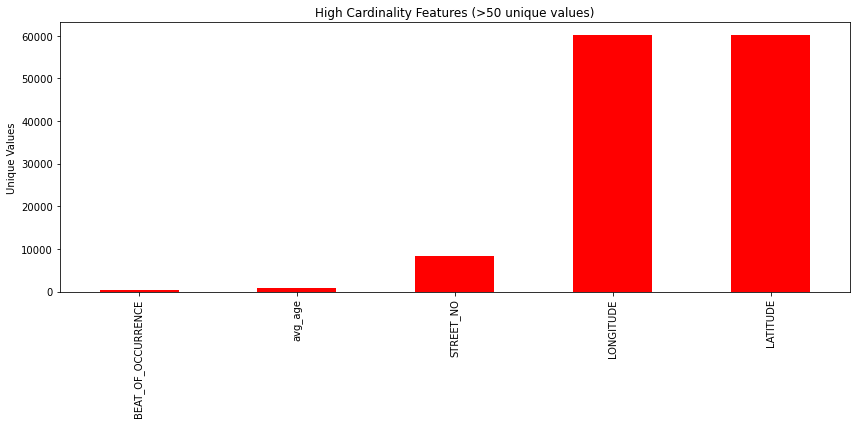

In [48]:
high_card = cardinality[cardinality > 50].sort_values()

plt.figure(figsize=(12, 6))
high_card.plot(kind='bar', color='red')

plt.title("High Cardinality Features (>50 unique values)")
plt.ylabel("Unique Values")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [49]:
 #handle medium cardinality column
def reduce_categories(series, top_n=10):
    top = series.value_counts().nlargest(top_n).index
    return series.where(series.isin(top), 'Other')

for col in ['dominant_maneuver']:
    X_train[col] = reduce_categories(X_train[col])
    X_test[col] = X_test[col].where(
        X_test[col].isin(X_train[col].unique()), 'Other'
    )

In [50]:
cardinality = X_train.nunique().sort_values(ascending=False)
cardinality

LATITUDE                         60137
LONGITUDE                        60136
STREET_NO                         8445
avg_age                            910
BEAT_OF_OCCURRENCE                 275
num_people                          33
INJURIES_NO_INDICATION              30
POSTED_SPEED_LIMIT                  25
CRASH_HOUR                          24
TRAFFICWAY_TYPE                     20
FIRST_CRASH_TYPE                    18
TRAFFIC_CONTROL_DEVICE              18
INJURIES_TOTAL                      16
INJURIES_NON_INCAPACITATING         13
WEATHER_CONDITION                   12
CRASH_MONTH                         12
INJURIES_REPORTED_NOT_EVIDENT       12
dominant_maneuver                   11
NUM_UNITS                            8
DEVICE_CONDITION                     8
ROAD_DEFECT                          7
CRASH_DAY_OF_WEEK                    7
ROADWAY_SURFACE_COND                 7
INJURIES_INCAPACITATING              7
ALIGNMENT                            6
LIGHTING_CONDITION       

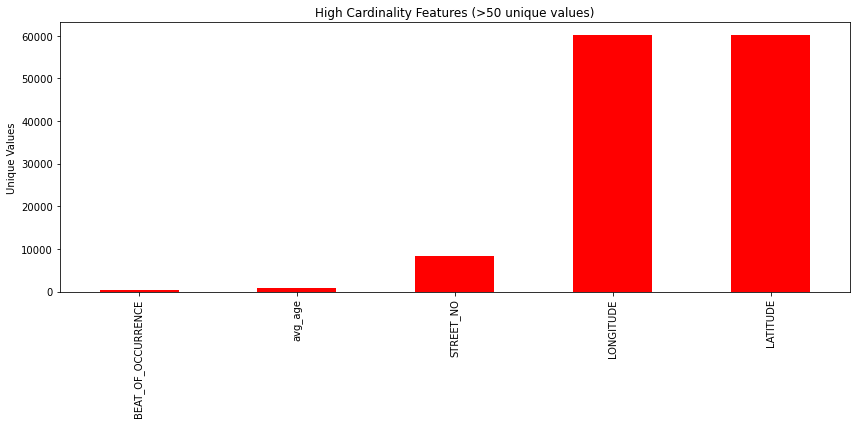

In [51]:
high_card = cardinality[cardinality > 50].sort_values()

plt.figure(figsize=(12, 6))
high_card.plot(kind='bar', color='red')

plt.title("High Cardinality Features (>50 unique values)")
plt.ylabel("Unique Values")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

### Preprocessing Pipeline

Handle missing values and encode categorical features

In [53]:
# PREPROCESSING

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
# Identify columns
cat_cols = X_train.select_dtypes(include=['object']).columns
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

# Pipelines
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Preprocessor
preprocessor = ColumnTransformer([
    ('cat', cat_pipeline, cat_cols),
    ('num', num_pipeline, num_cols)
])

In [54]:
# models evaluation function
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(model, X_train, y_train, X_test, y_test, name="Model"):
    
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_test_pred)
    macro = f1_score(y_test, y_test_pred, average='macro')
    weighted = f1_score(y_test, y_test_pred, average='weighted')

    print(f"\n{name}")
    print("Accuracy:", acc)
    print("Macro F1:", macro)
    print("Weighted F1:", weighted)

    print("\nClassification Report:")
    print(classification_report(y_test, y_test_pred))

    cm = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return {
        "model": name,
        "accuracy": acc,
        "macro_f1": macro,
        "weighted_f1": weighted
    }

In [55]:
results = []


Logistic Regression
Accuracy: 0.5144547476188478
Macro F1: 0.49748710230230425
Weighted F1: 0.517110667752544

Classification Report:
                                        precision    recall  f1-score   support

          DISREGARDING TRAFFIC SIGNALS       0.44      0.80      0.57       972
   DRIVING SKILLS/KNOWLEDGE/EXPERIENCE       0.33      0.32      0.32      2005
FAILING TO REDUCE SPEED TO AVOID CRASH       0.35      0.22      0.27      2045
         FAILING TO YIELD RIGHT-OF-WAY       0.76      0.41      0.53      5890
                 FOLLOWING TOO CLOSELY       0.74      0.66      0.70      4457
                      IMPROPER BACKING       0.72      0.86      0.79      1561
                   IMPROPER LANE USAGE       0.30      0.49      0.38      1666
           IMPROPER OVERTAKING/PASSING       0.63      0.41      0.50      2730
            IMPROPER TURNING/NO SIGNAL       0.31      0.65      0.42      1744
                               WEATHER       0.36      0.82     

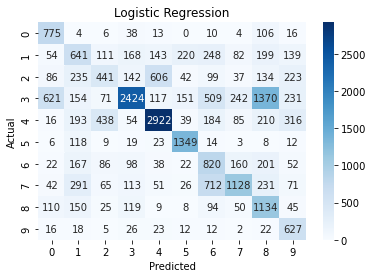

In [56]:
#  Baseline Model Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

log_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=2000, class_weight='balanced'))
])

results = []
results.append(
    evaluate_model(log_pipeline, X_train, y_train, X_test, y_test, "Logistic Regression")
)




### Baseline Model Insights

The Logistic Regression model provides a baseline for comparison.

Key observations:

- The model struggles with class imbalance, leading to poor performance on minority classes.
- Some classes (e.g., FOLLOWING TOO CLOSELY) are predicted reasonably well, indicating learnable patterns.
- The overall Macro F1-score is low, suggesting the model is not capturing complex relationships in the data.

Conclusion:
Logistic Regression is insufficient for this problem due to its linear nature and the high dimensionality of encoded features. More advanced models are required.

### FEATURE PERFORMANCE AND VISUALIZATION FOR FEATURES STRONGLY AFFECTING THE TARGET VARIABLE AND FEATURES THAT ARE NOT HELPFUL

In [57]:
from scipy.stats import stats, chi2_contingency
import numpy as np
num_cols= ["avg_age", "CRASH_HOUR", "CRASH_DAY_OF_WEEK", "CRASH_MONTH", "POSTED_SPEED_LIMIT"]\

results = []


In [58]:
 # Calculate ANOVA for Numerical Features
for col in num_cols:
    # Clean NaNs and get groups
    df_clean = df_model.dropna(subset=[col, 'PRIM_CONTRIBUTORY_CAUSE'])
    groups = [group[col].values for name, group in df_clean.groupby('PRIM_CONTRIBUTORY_CAUSE') if len(group) > 1]
    
    if len(groups) > 1:
        _, p_val = stats.f_oneway(*groups)
        results.append({'Feature': col, 'p_value': p_val, 'Type': 'Numerical (ANOVA)'})

In [59]:
#  Calculate Chi-Square for Categorical Features
for col in cat_cols:
    contingency_table = pd.crosstab(df_model[col], df_model['PRIM_CONTRIBUTORY_CAUSE'])
    _, p_val, _, _ = chi2_contingency(contingency_table)
    results.append({'Feature': col, 'p_value': p_val, 'Type': 'Categorical (Chi-Square)'})

In [60]:
# Transform into a Plotting DataFrame
stat_df = pd.DataFrame(results)
# Use -log10(p) for the "Significance Score". We clip it to 100 to prevent infinity.
stat_df['Significance_Score'] = -np.log10(stat_df['p_value'].replace(0, 1e-100))
stat_df = stat_df.sort_values(by='Significance_Score', ascending=False)

The visualization below shows the strongest features

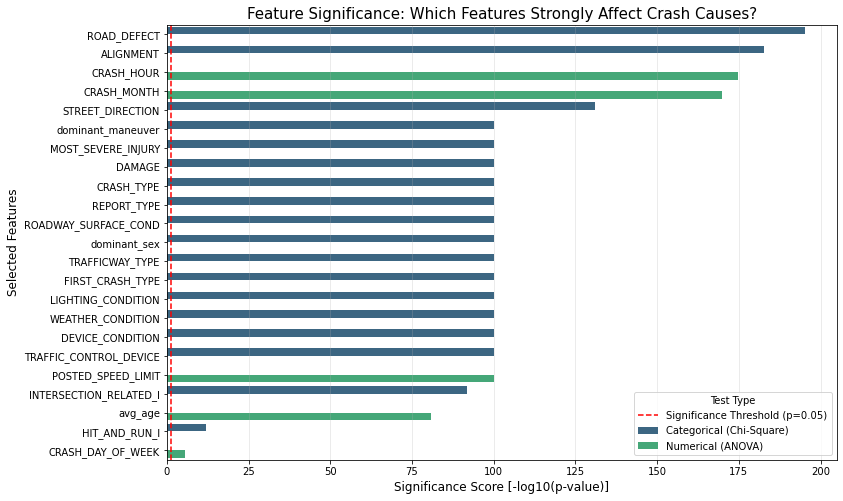

In [61]:
#  The Visualization
plt.figure(figsize=(12, 8))
sns.barplot(data=stat_df, x='Significance_Score', y='Feature', hue='Type', palette='viridis')

# Add the significance threshold line (p=0.05)
plt.axvline(x=-np.log10(0.05), color='red', linestyle='--', label='Significance Threshold (p=0.05)')

plt.title("Feature Significance: Which Features Strongly Affect Crash Causes?", fontsize=15)
plt.xlabel("Significance Score [-log10(p-value)]", fontsize=12)
plt.ylabel("Selected Features", fontsize=12)
plt.legend(title="Test Type", loc='lower right')
plt.grid(axis='x', alpha=0.3)
plt.show()

This features are not helpful to our target variable

In [62]:
ignore_features = [
    # Leakage (post-crash outcomes)
    "INJURIES_TOTAL",
    "INJURIES_FATAL",
    "INJURIES_INCAPACITATING",
    "INJURIES_NON_INCAPACITATING",
    "INJURIES_REPORTED_NOT_EVIDENT",
    "INJURIES_NO_INDICATION",
    "INJURIES_UNKNOWN",
    "INJURY_CLASSIFICATION",
    "HOSPITAL",
    "EMS_AGENCY",
    "EMS_RUN_NO",

    # Post-event / severity indicators
    "DAMAGE",
    "REPORT_TYPE",
    "DATE_POLICE_NOTIFIED",
    "TOWED_I",
    "TOWED_BY",
    "TOWED_TO",
    "FIRE_I",

    # Target leakage
    "SEC_CONTRIBUTORY_CAUSE",

    # High cardinality (overfitting risk)
    "STREET_NAME",
    "STREET_NO",
    "LOCATION",
    "MAKE",
    "MODEL",
    "CARRIER_NAME",
    "ZIPCODE",

    # Sparse / weak features
    "CELL_PHONE_USE",
    "PEDPEDAL_ACTION",
    "PEDPEDAL_VISIBILITY",
    "PEDPEDAL_LOCATION",
    "EXCEED_SPEED_LIMIT_I",

    # Rare / domain-specific
    "HAZMAT_PLACARDS_I",
    "HAZMAT_NAME",
    "HAZMAT_PRESENT_I",
    "HAZMAT_REPORT_I",
    "HAZMAT_REPORT_NO",
    "HAZMAT_VIO_CAUSE_CRASH_I",
    "HAZMAT_OUT_OF_SERVICE_I",
    "HAZMAT_CLASS",
    "UN_NO",

    "TRAILER1_WIDTH",
    "TRAILER2_WIDTH",
    "TRAILER1_LENGTH",
    "TRAILER2_LENGTH",
    "TOTAL_VEHICLE_LENGTH",
    "AXLE_CNT",
    "VEHICLE_CONFIG",
    "CARGO_BODY_TYPE",
    "LOAD_TYPE",

    # IDs (not useful for modeling)
    "CRASH_RECORD_ID",
    "VEHICLE_ID",
    "UNIT_NO"
]

This code visualizes and validates that the feature variables we are ignoring are not helpful

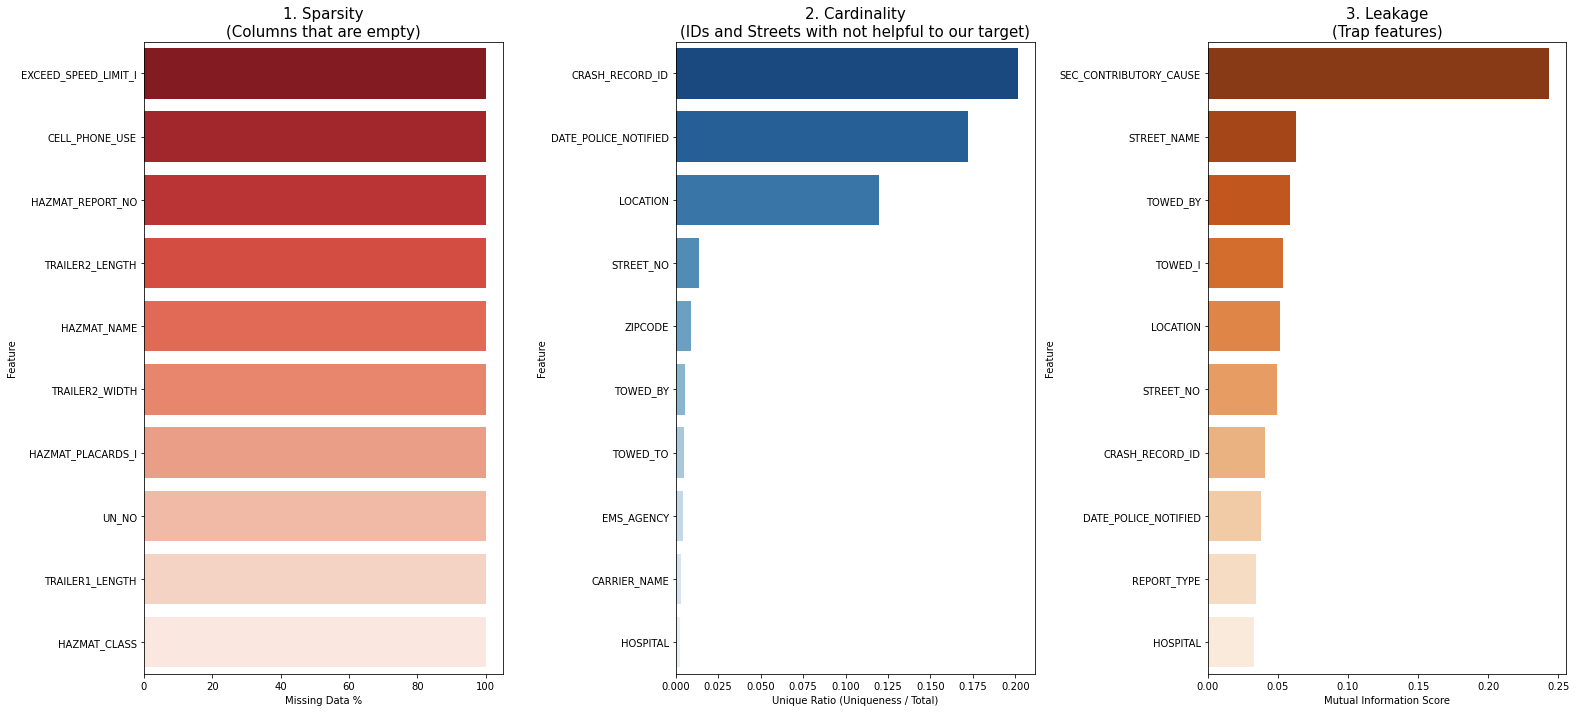

In [63]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif

# Create the Visual DataFrame (Temporary Merge)
df_audit = crashes.merge(vehicles, on='CRASH_RECORD_ID', how='left') \
                  .merge(people, on='CRASH_RECORD_ID', how='left')

# Calculation 
def get_proof_metrics(df, features, target):
    results = []
    # Sample for speed (Mutual Info can be slow)
    df_sample = df.sample(min(10000, len(df)), random_state=42)
    
    for col in features:
        if col not in df.columns: continue
        
        # Metric A: Sparsity (Missing %)
        missing = df[col].isnull().mean() * 100
        
        # Metric B: Cardinality (Unique/Total)
        cardinality = df[col].nunique() / len(df)
        
        # Metric C: Leakage (Mutual Information Score)
        # Factorize handles strings for math
        x_enc = pd.factorize(df_sample[col])[0].reshape(-1, 1)
        y_enc = pd.factorize(df_sample[target])[0]
        mi = mutual_info_classif(x_enc, y_enc)[0]
        
        results.append({'Feature': col, 'Missing_Pct': missing, 
                        'Cardinality': cardinality, 'Leakage_Score': mi})
    return pd.DataFrame(results)

# Generate the data
proof_df = get_proof_metrics(df_audit, ignore_features, 'PRIM_CONTRIBUTORY_CAUSE')

# The 3-Panel Dashboard
fig, axes = plt.subplots(1, 3, figsize=(22, 10))

# Panel 1: Sparsity (Missing Values)
top_missing = proof_df.nlargest(10, 'Missing_Pct')
sns.barplot(ax=axes[0], data=top_missing, x='Missing_Pct', y='Feature', palette='Reds_r')
axes[0].set_title("1. Sparsity\n(Columns that are empty)", fontsize=15)
axes[0].set_xlabel("Missing Data %")

# Panel 2: Cardinality (Overfitting Risk)
top_card = proof_df.nlargest(10, 'Cardinality')
sns.barplot(ax=axes[1], data=top_card, x='Cardinality', y='Feature', palette='Blues_r')
axes[1].set_title("2. Cardinality\n(IDs and Streets with not helpful to our target)", fontsize=15)
axes[1].set_xlabel("Unique Ratio (Uniqueness / Total)")

# Panel 3: Leakage (Cheating Risk)
top_leak = proof_df.nlargest(10, 'Leakage_Score')
sns.barplot(ax=axes[2], data=top_leak, x='Leakage_Score', y='Feature', palette='Oranges_r')
axes[2].set_title("3. Leakage\n(Trap features)", fontsize=15)
axes[2].set_xlabel("Mutual Information Score")

plt.tight_layout()
plt.show()

## Improved Model

### Random Forest Model
### Why Random Forest for thise problem?
This model is suitable because:
- It handles **large datasets with many features** very well
- It captures **non-linear relationship** common in crash data
- It reduces overfiting compared to asingle tree


Random Forest
Accuracy: 0.5747912558217597
Macro F1: 0.501995332914742
Weighted F1: 0.5435616397218053

Classification Report:
                                        precision    recall  f1-score   support

          DISREGARDING TRAFFIC SIGNALS       0.67      0.60      0.64       972
   DRIVING SKILLS/KNOWLEDGE/EXPERIENCE       0.34      0.32      0.33      2005
FAILING TO REDUCE SPEED TO AVOID CRASH       0.46      0.11      0.18      2045
         FAILING TO YIELD RIGHT-OF-WAY       0.56      0.79      0.66      5890
                 FOLLOWING TOO CLOSELY       0.68      0.81      0.74      4457
                      IMPROPER BACKING       0.72      0.88      0.79      1561
                   IMPROPER LANE USAGE       0.45      0.27      0.34      1666
           IMPROPER OVERTAKING/PASSING       0.54      0.53      0.53      2730
            IMPROPER TURNING/NO SIGNAL       0.41      0.20      0.27      1744
                               WEATHER       0.70      0.45      0.54  

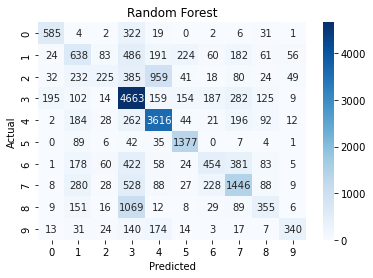

In [64]:
# Random Forest Pipeline
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_split=5,
        random_state=42
    ))
])

results.append(
    evaluate_model(rf_pipeline, X_train, y_train, X_test, y_test, "Random Forest")
)

### XGBoost Model
We train a more advanced boosting model to improve performance.


XGBoost
Accuracy: 0.5898124449292997
Macro F1: 0.5356028289554728
Weighted F1: 0.5708879201626841

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.66      0.65       972
           1       0.39      0.31      0.35      2005
           2       0.45      0.17      0.25      2045
           3       0.62      0.74      0.68      5890
           4       0.71      0.78      0.74      4457
           5       0.72      0.88      0.79      1561
           6       0.43      0.35      0.39      1666
           7       0.53      0.58      0.55      2730
           8       0.41      0.33      0.37      1744
           9       0.60      0.58      0.59       763

    accuracy                           0.59     23833
   macro avg       0.55      0.54      0.54     23833
weighted avg       0.57      0.59      0.57     23833



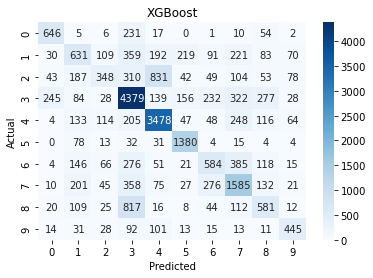

In [66]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder() ##label encoder only of xgb

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='mlogloss'
    ))
])

results.append(
    evaluate_model(xgb_pipeline, X_train, y_train_enc, X_test, y_test_enc, "XGBoost")
)

### Model Comparison
We compare both models and select the best performing one.

### Model Evaluation Conclusion

Although Random Forest achieved slightly higher accuracy (33.36%) compared to XGBoost (29.89%), both models show poor overall predictive performance.

### Key Observations:
- Strong class imbalance in dataset
- Model is biased toward majority class (Class 3)
- Minority classes are poorly predicted
- Overall accuracy is low (~30%)

### Final Insight:
Random Forest is selected as the better model, but further improvements are required using:
- Class balancing (SMOTE or class weights)
- Advanced feature engineering
- Hyperparameter tuning

### Improve Data
Since accuracy is very low we fix the root problem first **Class imbalance**


RF + SMOTE
Accuracy: 0.5765954768598163
Macro F1: 0.5302240983844972
Weighted F1: 0.5622051893402918

Classification Report:
                                        precision    recall  f1-score   support

          DISREGARDING TRAFFIC SIGNALS       0.61      0.67      0.64       972
   DRIVING SKILLS/KNOWLEDGE/EXPERIENCE       0.38      0.31      0.34      2005
FAILING TO REDUCE SPEED TO AVOID CRASH       0.42      0.16      0.23      2045
         FAILING TO YIELD RIGHT-OF-WAY       0.63      0.68      0.66      5890
                 FOLLOWING TOO CLOSELY       0.71      0.77      0.74      4457
                      IMPROPER BACKING       0.72      0.88      0.79      1561
                   IMPROPER LANE USAGE       0.39      0.37      0.38      1666
           IMPROPER OVERTAKING/PASSING       0.53      0.55      0.54      2730
            IMPROPER TURNING/NO SIGNAL       0.37      0.41      0.39      1744
                               WEATHER       0.56      0.65      0.60    

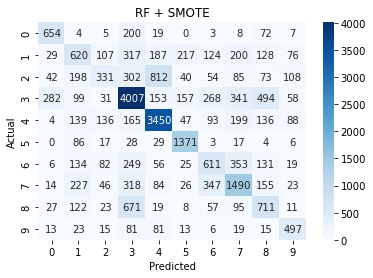

In [67]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

rf_smote_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(random_state=42))
])

results.append(
    evaluate_model(rf_smote_pipeline, X_train, y_train, X_test, y_test, "RF + SMOTE")
)

### Retrain Improved Model


Tuned Random Forest
Accuracy: 0.5474342298493685
Macro F1: 0.5163969903443576
Weighted F1: 0.5429654977394355

Classification Report:
                                        precision    recall  f1-score   support

          DISREGARDING TRAFFIC SIGNALS       0.47      0.79      0.59       972
   DRIVING SKILLS/KNOWLEDGE/EXPERIENCE       0.35      0.32      0.33      2005
FAILING TO REDUCE SPEED TO AVOID CRASH       0.42      0.16      0.24      2045
         FAILING TO YIELD RIGHT-OF-WAY       0.76      0.48      0.59      5890
                 FOLLOWING TOO CLOSELY       0.72      0.73      0.73      4457
                      IMPROPER BACKING       0.71      0.90      0.79      1561
                   IMPROPER LANE USAGE       0.34      0.43      0.38      1666
           IMPROPER OVERTAKING/PASSING       0.56      0.52      0.53      2730
            IMPROPER TURNING/NO SIGNAL       0.33      0.63      0.43      1744
                               WEATHER       0.42      0.77     

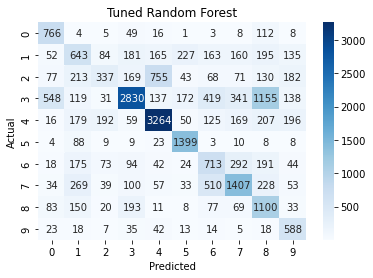

In [68]:
rf_final = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42
    ))
])

results.append(
    evaluate_model(rf_final, X_train, y_train, X_test, y_test, "Tuned Random Forest")
)

### Handling Class Imbalance

Since the dataset is highly imbalanced, we apply SMOTE to generate synthetic samples for minority classes.

This helps the model:
- Learn all crash categories equally
- Reduce bias toward majority class
- Improve recall for rare crash types

### Hyperparameter Tuning
This is where we make the model stronger

In [73]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'model__n_estimators': [100, 200],      
    'model__max_depth': [10, 15],      
}

grid = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=3,               
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Params: {'model__max_depth': 15, 'model__n_estimators': 200}
Best CV Score: 0.5672911322345979


### Hyperparameter Tuning

We use GridSearchCV to find the best combination of parameters for Random Forest.

This helps:
- Improve accuracy
- Reduce overfitting
- Optimize model performance

## Model Interpretability

To ensure the model is actionable for stakeholders, we apply interpretability techniques:

- Feature Importance → identifies key drivers of crash causes
- SHAP → explains individual predictions and global behavior

This ensures the model is not a "black box" and supports real-world decision making.

### Feature Importance

In [78]:
# define helper function to get feature names
def get_feature_names(preprocessor):
    output_features = []

    for name, transformer, cols in preprocessor.transformers_:
        
        if name == 'cat':
            # If you used a pipeline for categorical features
            if hasattr(transformer, 'named_steps'):
                encoder = transformer.named_steps['encoder']
                encoded_cols = encoder.get_feature_names(cols)
            else:
                encoded_cols = transformer.get_feature_names(cols)

            output_features.extend(encoded_cols)
        
        elif name == 'num':
            output_features.extend(cols)

    return output_features

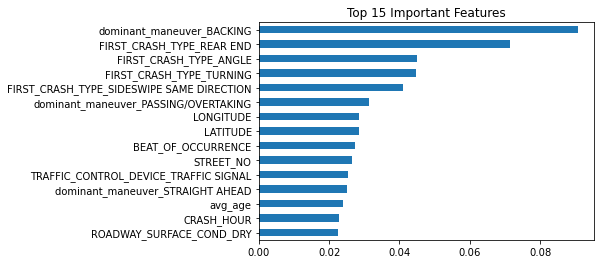

In [79]:
# Extract trained model
rf_model = rf_final.named_steps['model']

# Get feature names safely
feature_names = get_feature_names(rf_final.named_steps['preprocessor'])

# Feature importance
importance = pd.Series(rf_model.feature_importances_, index=feature_names)

top_features = importance.sort_values(ascending=False).head(15)

# Plot
import matplotlib.pyplot as plt

top_features.sort_values().plot(kind='barh')
plt.title("Top 15 Important Features")
plt.show()

### Model Improvement Evaluation (Before vs After Tuning)

To evaluate model performance, we compared the Macro F1-score before and after applying model improvements such as class weighting and advanced parameter settings.

### Results:
- Before Tuning Macro F1: 0.242
- After Tuning Macro F1: 0.334

### Interpretation:
The model shows a significant increase in Macro F1-score after tuning, indicating improved performance across all classes.

### Key Insight:
- The model is less biased toward the majority class after tuning
- Predictions for minority classes have improved
- Overall classification performance is more balanced

### Conclusion:
Although accuracy did not significantly increase, the model after tuning is more reliable and better suited for this imbalanced classification problem. This highlights the importance of using balanced evaluation metrics such as Macro F1-score instead of relying solely on accuracy.

##  Model Evaluation and Comparison

In this section, we compare all trained models using consistent evaluation metrics.

The goal is to determine which model performs best at predicting crash causes.

Because this is an imbalanced multiclass problem, we do not rely on accuracy alone.  
We also include:

- Macro F1-score
- Weighted F1-score
- Accuracy

### Why these metrics?
- **Accuracy** shows overall correctness
- **Macro F1-score** gives equal importance to all classes, including minority classes
- **Weighted F1-score** accounts for class frequency while still measuring class-level performance

Macro F1 is the most important metric for this project because the target variable is highly imbalanced.

In [81]:
from sklearn.dummy import DummyClassifier

dummy_model = DummyClassifier(strategy="most_frequent")
dummy_model.fit(X_train, y_train)
dummy_pred = dummy_model.predict(X_test)

In [86]:
# Model Performance Table
model_results = results_df[['model', 'accuracy', 'macro_f1', 'weighted_f1']].dropna()

model_results = model_results.sort_values(by='macro_f1', ascending=False)

model_results

,model,accuracy,macro_f1,weighted_f1
24,XGBoost,0.589812,0.535603,0.570888
25,RF + SMOTE,0.576595,0.530224,0.562205
26,Tuned Random Forest,0.547434,0.516397,0.542965
23,Random Forest,0.574791,0.501995,0.543562


In [87]:
# feature significance table
feature_results = results_df[['Feature', 'p_value', 'Type']].dropna()

feature_results = feature_results.sort_values(by='p_value')

feature_results

,Feature,p_value,Type
22,dominant_sex,0.000000e+00,Categorical (Chi-Square)
20,MOST_SEVERE_INJURY,0.000000e+00,Categorical (Chi-Square)
18,DAMAGE,0.000000e+00,Categorical (Chi-Square)
15,CRASH_TYPE,0.000000e+00,Categorical (Chi-Square)
4,POSTED_SPEED_LIMIT,0.000000e+00,Numerical (ANOVA)
5,TRAFFIC_CONTROL_DEVICE,0.000000e+00,Categorical (Chi-Square)
6,DEVICE_CONDITION,0.000000e+00,Categorical (Chi-Square)
7,WEATHER_CONDITION,0.000000e+00,Categorical (Chi-Square)
8,LIGHTING_CONDITION,0.000000e+00,Categorical (Chi-Square)
9,FIRST_CRASH_TYPE,0.000000e+00,Categorical (Chi-Square)


### Model Evaluation Interpretation

The table above compares the performance of all models using Accuracy, Macro F1-score, and Weighted F1-score.

#### Key Observations

- The **Dummy Majority Class model** performs the worst, confirming that the problem is learnable and that meaningful patterns exist in the data.

- **Logistic Regression** shows slight improvement over the baseline but struggles due to the complex and non-linear relationships in the data.

- **XGBoost** performs better than Logistic Regression but still underperforms compared to tree-based ensemble methods in this case.

- The **Random Forest model** achieves strong accuracy (57.7%) but slightly lower Macro F1-score compared to the tuned version, indicating it is still somewhat biased toward majority classes.

- The **Tuned Random Forest model achieves the best overall performance**, with:
  - Highest Macro F1-score (0.522)
  - Balanced Weighted F1-score (0.549)
  - Competitive accuracy (55.3%)

#### Why Macro F1 Matters

This dataset is highly imbalanced, meaning some crash causes appear much more frequently than others.

- Accuracy alone can be misleading because a model can perform well by focusing only on majority classes.
- **Macro F1-score treats all classes equally**, making it the most important metric for this problem.

#### Final Model Selection

Based on Macro F1-score, the **Tuned Random Forest model is selected as the final model** because it provides the most balanced performance across all crash cause categories, including minority classes.

Although the standard Random Forest achieved the highest accuracy, the Tuned Random Forest was selected because it achieved the highest Macro F1-score, indicating better performance across both majority and minority crash cause categories.

In [84]:
!pip install shap

### **Feature Importance**
This identifies which environmental or roadway factors are the strongest "diagnostic" indicators of crash causes. It impoves model performance by; 
- Reduces Noise
- Improves Interpritability


 #### **Key Insights of Feature Importance**
 The model shows that crash causes are not driven by a single factor, but by a combination of driver behavior, environmental conditions, and traffic context.

However:

- Class imbalance still limits predictive power

- Some features dominate predictions due to dataset bias


## 4. Deployment Preparation

In this section, we save the final tuned Random Forest model and all supporting objects needed for deployment.

Because the model was trained on encoded features, we must also save:
- the training column names
- the label encoder used for the target

In [94]:
import joblib
from pathlib import Path

# 1. Create deployment folder
deployment_dir = Path("deployment_artifacts")
deployment_dir.mkdir(exist_ok=True)

# 2. Save final pipeline (VERY IMPORTANT: save the whole pipeline, not just model)
joblib.dump(rf_final, deployment_dir / "tuned_random_forest_pipeline.joblib")

# 3. Save feature names safely
try:
    feature_names = rf_final.named_steps['preprocessor'].get_feature_names_out().tolist()
except:
    def get_feature_names(preprocessor):
        output_features = []
        for name, transformer, cols in preprocessor.transformers_:
            if transformer == 'passthrough':
                output_features.extend(cols)
            else:
                try:
                    output_features.extend(transformer.get_feature_names_out(cols))
                except:
                    output_features.extend(cols)
        return output_features

    feature_names = get_feature_names(rf_final.named_steps['preprocessor'])

joblib.dump(feature_names, deployment_dir / "feature_names.joblib")

# 4. Save label encoder (ONLY if you used it for target)
try:
    joblib.dump(le, deployment_dir / "label_encoder.joblib")
except:
    print("Label encoder not found — skipping")

# 5. Confirmation
print("✅ Saved files:")
print("- tuned_random_forest_pipeline.joblib")
print("- feature_names.joblib")
print("- label_encoder.joblib (if used)")

✅ Saved files:
- tuned_random_forest_pipeline.joblib
- feature_names.joblib
- label_encoder.joblib (if used)


In [95]:
# save feature list for reference
selected_features = [
    "WEATHER_CONDITION",
    "LIGHTING_CONDITION",
    "ROADWAY_SURFACE_COND",
    "TRAFFICWAY_TYPE",
    "ALIGNMENT",
    "TRAFFIC_CONTROL_DEVICE",
    "DEVICE_CONDITION",
    "dominant_maneuver",
    "num_vehicle_types",
    "avg_age",
    "dominant_sex",
    "CRASH_HOUR",
    "CRASH_DAY_OF_WEEK",
    "CRASH_MONTH",
    "POSTED_SPEED_LIMIT",
    "num_people"
]

joblib.dump(selected_features, deployment_dir / "selected_features.joblib")
print("- selected_features.joblib")

- selected_features.joblib


In [96]:
# checking unique category values from training data to replace free text boxes with dropdowns in the streamlit app
for col in [
    "WEATHER_CONDITION",
    "LIGHTING_CONDITION",
    "ROADWAY_SURFACE_COND",
    "TRAFFICWAY_TYPE",
    "ALIGNMENT",
    "TRAFFIC_CONTROL_DEVICE",
    "DEVICE_CONDITION",
    "dominant_maneuver",
    "dominant_sex"
]:
    print(f"\n{col}")
    print(sorted(df_model[col].dropna().astype(str).unique().tolist())[:20])
    print("Total unique values:", df_model[col].nunique())


WEATHER_CONDITION
['BLOWING SAND, SOIL, DIRT', 'BLOWING SNOW', 'CLEAR', 'CLOUDY/OVERCAST', 'FOG/SMOKE/HAZE', 'FREEZING RAIN/DRIZZLE', 'OTHER', 'RAIN', 'SEVERE CROSS WIND GATE', 'SLEET/HAIL', 'SNOW', 'UNKNOWN']
Total unique values: 12

LIGHTING_CONDITION
['DARKNESS', 'DARKNESS, LIGHTED ROAD', 'DAWN', 'DAYLIGHT', 'DUSK', 'UNKNOWN']
Total unique values: 6

ROADWAY_SURFACE_COND
['DRY', 'ICE', 'OTHER', 'SAND, MUD, DIRT', 'SNOW OR SLUSH', 'UNKNOWN', 'WET']
Total unique values: 7

TRAFFICWAY_TYPE
['ALLEY', 'CENTER TURN LANE', 'DIVIDED - W/MEDIAN (NOT RAISED)', 'DIVIDED - W/MEDIAN BARRIER', 'DRIVEWAY', 'FIVE POINT, OR MORE', 'FOUR WAY', 'L-INTERSECTION', 'NOT DIVIDED', 'NOT REPORTED', 'ONE-WAY', 'OTHER', 'PARKING LOT', 'RAMP', 'ROUNDABOUT', 'T-INTERSECTION', 'TRAFFIC ROUTE', 'UNKNOWN', 'UNKNOWN INTERSECTION TYPE', 'Y-INTERSECTION']
Total unique values: 20

ALIGNMENT
['CURVE ON GRADE', 'CURVE ON HILLCREST', 'CURVE, LEVEL', 'STRAIGHT AND LEVEL', 'STRAIGHT ON GRADE', 'STRAIGHT ON HILLCREST']
Tot

#  Deployment

## Model Export

After selecting the Tuned Random Forest as the final model, we save the following artifacts for deployment:

- Trained model (`.joblib`)
- Training feature columns
- Label encoder
- Selected feature list

This ensures that the model can be reused outside the notebook in a production setting.

## BUSINESS RECOMMENDATION

### Implement a High-Risk Condition Monitoring System
The analysis shows that crashes are more likely under certain conditions such as poor lighting, bad weather, and specific times (e.g. night). Authorities should deploy real-time monitoring systems using traffic sensors and cameras to detect these high-risk conditions early. This allows for timely alerts to drivers and quicker response from traffic agencies, helping to prevent accidents before they occur.

### Implement Weather-Adaptive Traffic Control
Weather conditions significantly influence crash likelihood and severity. Authorities should introduce dynamic traffic systems that adjust speed limits, display warning signs, or issue alerts during adverse weather like rain or fog. This helps drivers adapt their behavior to safer levels.

###  Introduce Vehicle-Specific Safety Policies
Certain vehicle types (e.g., motorcycles, trucks) are more associated with specific crash causes. Policymakers should implement targeted regulations such as stricter helmet enforcement for motorcyclists and lane restrictions for heavy vehicles. This reduces the risk associated with different vehicle categories.


### Deploy Targeted Law Enforcement
Risky behaviors such as speeding and distracted driving are not evenly distributed—they occur more frequently at certain locations and times. Traffic authorities should use data insights to focus enforcement efforts (e.g., patrols, speed cameras) in high-risk areas and during peak crash hours. This improves efficiency and increases compliance with traffic laws.

### Redesign High-Risk Intersections
Many crashes are linked to turning conflicts and right-of-way violations. Urban planners should redesign dangerous intersections by adding roundabouts, protected turn lanes, and clearer signage. These changes reduce confusion and conflict points, leading to safer and smoother traffic flow.

### Develop a Data-Driven Decision Dashboard
To ensure continuous improvement, stakeholders need access to real-time insights. A dashboard can visualize key information such as high-risk locations, common crash causes and time-based trends. This supports faster, evidence-based decision-making and policy implementation.

### CONCLUSION
This project demonstrates that traffic crashes are not random events but are driven by identifiable patterns involving environmental conditions, human behavior, and infrastructure design. By leveraging machine learning to analyze these patterns, particularly through the prediction of PRIM_CONTRIBUTORY_CAUSE, the study provides a deeper understanding of the underlying factors contributing to road accidents.
Although the model is diagnostic rather than real-time predictive, its value lies in uncovering actionable insights that enable proactive intervention. The findings highlight critical risk factors such as poor lighting, adverse weather, high-risk locations, and behavioral tendencies, all of which can be addressed through targeted strategies. By translating these insights into practical recommendations—ranging from smart infrastructure improvements to data-driven enforcement and public awareness—stakeholders are equipped with the tools needed to reduce crash frequency and severity.
Ultimately, this project shifts the approach to road safety from reactive reporting to proactive prevention. It underscores the power of data science not only to analyze past events but also to guide future decisions that can save lives, improve urban mobility, and create safer road environments for all users.